# 🏎️ Formula Student Driverless — Aprendizagem por Reforço

#### *Notebook de avaliação · resultados reproduzíveis ao vivo*

**Mestrado em Inteligência Artificial · Universidade do Minho · 2025/26**
**Grupo 1:** Luís Miguel Pereira Silva (PG60390) · Pedro Miguel S. A. Urbano dos Reis (PG59908)

---

Um agente de RL aprende a conduzir um carro de *Formula Student Driverless* numa pista de cones, sob regras FS-AI. Este notebook acompanha o relatório (`docs/report.pdf`) e reúne, num só sítio, os **resultados principais** — reproduzíveis ao vivo sobre os modelos treinados.

> **Como usar:** `Kernel → Restart & Run All`.
> • Secções **3–6** usam resultados pré-computados (segundos, sem GPU).
> • Secções **2, 7 e 8** correm modelos treinados ao vivo em **CPU** (~0.5 s/episódio; a 1.ª geração de GIFs demora um pouco, depois fica em cache).

**Índice**

| # | Secção |
|--:|---|
| **0** | Setup e verificação do ambiente |
| **1** | O problema e o ambiente de simulação |
| **2** | Reward shaping — componentes, animação e a **ablação de reward** (6 iterações) |
| **3** | Resultados principais: SAC vs PPO |
| **4** | Curvas de aprendizagem (eficiência de amostras) |
| **5** | Ablações controladas |
| **6** | Viés direcional e *mirror augmentation* (descoberta principal) |
| **7** | Avaliação ao vivo de um modelo treinado |
| **8** | Demonstração final: um sucesso e uma falha |
| **9** | Como reproduzir tudo a partir da linha de comandos |

## 0. Setup e verificação do ambiente

Localizamos a raiz do repositório (o notebook funciona quer seja aberto a partir de `notebooks/` quer da raiz), importamos as bibliotecas e verificamos que dependências estão disponíveis.

In [1]:
import os, sys

# --- localizar a raiz do repositório (procura results/aggregated) ---
def find_root(start):
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.isdir(os.path.join(d, "results", "aggregated")):
            return d
        d = os.path.dirname(d)
    raise RuntimeError("Não encontrei a raiz do repositório (results/aggregated).")

ROOT = find_root(os.getcwd())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
AGG = os.path.join(ROOT, "results", "aggregated")
print("Raiz do repositório:", ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Funções de plot partilhadas com o relatório (scripts/make_report_figures.py)
from scripts.make_report_figures import (
    plot_sac_vs_ppo, plot_direction_bias, plot_ablations, _mean,
)

# Que dependências de avaliação ao vivo existem?
def _has(mod):
    try:
        __import__(mod); return True
    except Exception:
        return False
HAVE_SB3 = _has("stable_baselines3")
HAVE_ENV = _has("gymnasium")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"stable-baselines3 disponível: {HAVE_SB3} | gymnasium disponível: {HAVE_ENV}")


Raiz do repositório: /home/luismpso/Documentos/github/AR2
pandas 3.0.3 | numpy 2.3.5
stable-baselines3 disponível: True | gymnasium disponível: True


## 1. O problema e o ambiente de simulação

O agente conduz um carro de Formula Student *Driverless* numa pista delimitada por cones — **azuis** (fronteira esquerda), **amarelos** (direita) e **laranja** (partida/chegada). O ambiente (`env/racing_env.py`, API *Gymnasium*) integra:

- **Modelo cinemático de bicicleta** (~250 kg, *friction circle*, *rate limiting* no *steering*);
- **Sensor de cones** com ruído (FOV 180°, 15 m, 95 % de deteção) — o agente vê só os 3 cones mais próximos de cada cor, **sem** acesso à *centerline*;
- **14 pistas reais de competição** (formato YAML) + gerador procedural;
- **Regras FS-AI**: +2 s por cone, DOO (≥10 cones / *off-course*), *off-course* gradual.

**Observação** ∈ ℝ²⁴ (6 de estado do veículo + 18 de cones) · **Ação** ∈ [−1,1]² (*steering*, *throttle*/travão).

Abaixo visualizamos uma das pistas de teste (cones reais carregados do YAML).

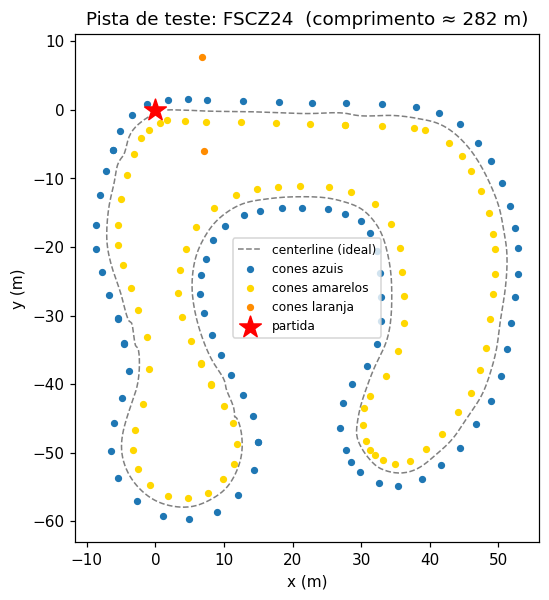

In [2]:
# Visualização de uma pista real (cones + centerline)
TRACK = "FSCZ24"   # experimenta: FSG24, FSI24, FSE24, FSS22_V2
try:
    from env.track_loader import YAMLTrackLoader
    loader = YAMLTrackLoader(os.path.join(ROOT, "tracks"))
    td = loader.load_track(name=TRACK)
    fig, ax = plt.subplots(figsize=(7, 6))
    cl = td["centerline"]
    ax.plot(cl[:, 0], cl[:, 1], "--", color="gray", lw=1, label="centerline (ideal)")
    for key, c, lab in [("blue_cones", "tab:blue", "cones azuis"),
                        ("yellow_cones", "gold", "cones amarelos"),
                        ("orange_cones", "darkorange", "cones laranja")]:
        pts = td.get(key, np.zeros((0, 2)))
        if len(pts):
            ax.scatter(pts[:, 0], pts[:, 1], s=14, color=c, label=lab)
    sp = td["start_pos"]
    ax.scatter([sp[0]], [sp[1]], marker="*", s=220, color="red", zorder=5, label="partida")
    ax.set_aspect("equal"); ax.legend(loc="best", fontsize=8)
    ax.set_title(f"Pista de teste: {TRACK}  (comprimento ≈ {td['track_length']:.0f} m)")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    plt.show()
except Exception as e:
    print("Visualização indisponível (precisa de gymnasium/scipy):", repr(e))


## 2. Reward shaping — como guiamos a aprendizagem

A recompensa por *step* combina vários termos, cada um com um peso calibrado. O **progresso** ao longo da *centerline* é o sinal dominante; os restantes moldam um comportamento rápido, alinhado, suave e dentro da pista. Penalizações por cone (−8, ou −16 nos laranja) e o bónus de volta (+200) calibram os comportamentos-limite.

| Componente | Descrição | Peso |
|---|---|---|
| `r_progress` | distância percorrida na *centerline* (com sinal) | ×2.0 |
| `r_alignment` | v·cos(erro de *heading*) — rápido **e** alinhado | ×0.4 |
| `r_smooth` | penaliza Δ*steering* acima de *dead-band* 0.1 | ×0.05 |
| `r_lateral` | linear dentro da pista, quadrática fora | ×0.08 |
| `r_time` | custo fixo por *step* (encoraja velocidade) | −0.005 |
| *cone hit* | por cone azul/amarelo (laranja ×2) | −8 / −16 |
| *lap bonus* | por volta completa (descontado pelos cones) | +200 |

Abaixo corremos um modelo treinado numa volta e **decompomos a recompensa** nos seus componentes (mesmas fórmulas de `env/racing_env.py`): à esquerda a evolução ao longo da volta, à direita a contribuição total de cada termo no episódio. 🎬 Há também uma demonstração em vídeo em [`docs/rewardshaping.mp4`](../docs/rewardshaping.mp4).

[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


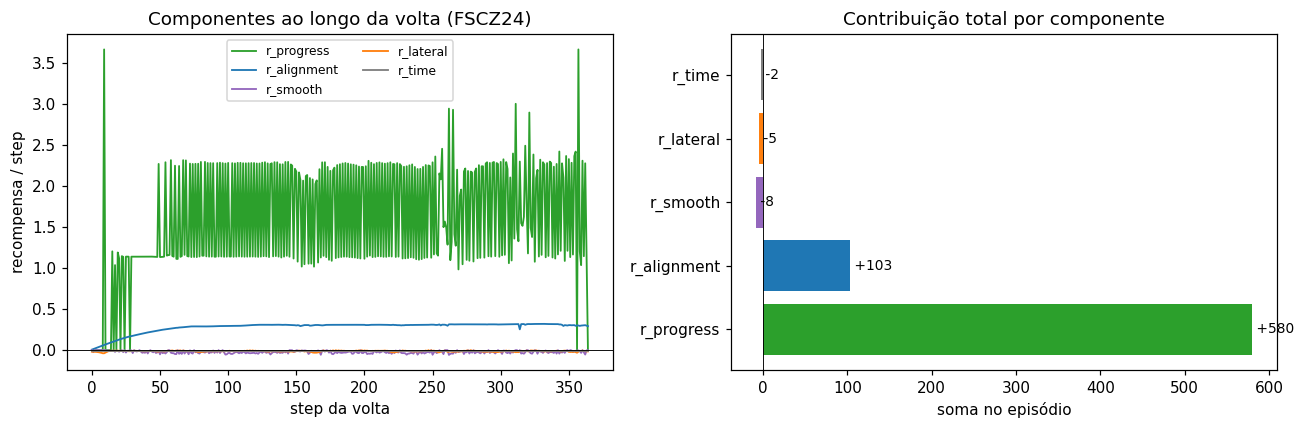

Volta FSCZ24: laps=1 | cones=0 | o progresso domina o retorno (Σr_progress ≈ +580).


In [3]:
RS_MODEL = "runs/sac_seed0/best/best_model.zip"
RS_TRACK = "FSCZ24"

def reward_components_rollout(model_path, track):
    # Corre uma volta e recompõe cada termo da reward (idêntico a _compute_reward).
    from stable_baselines3 import SAC
    from env.racing_env import FSRacingEnv
    model = SAC.load(os.path.join(ROOT, model_path), device="cpu")
    env = FSRacingEnv(render_mode=None, randomize_track=False, domain_randomization=False,
                      max_episode_steps=3000, tracks_dir=os.path.join(ROOT, "tracks"),
                      track_name=track, use_orange_cones=True, terminate_on_cone=False,
                      doo_cone_limit=999, max_laps=1)
    obs, info = env.reset(seed=0)
    vmax = env.vehicle_params.max_speed
    prev_prog, prev_steer = 0.0, 0.0
    comps = {k: [] for k in ["r_progress", "r_alignment", "r_smooth", "r_lateral", "r_time"]}
    done = False
    while not done:
        a, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(a)
        done = term or trunc
        cl = env.track_data["centerline"]
        d2 = np.sum((cl - np.array([env.car.x, env.car.y]))**2, axis=1)
        cl_idx = int(np.argmin(d2))
        lateral = float(np.sqrt(d2[cl_idx]))
        hw = env._get_effective_hw()
        hdg = env._get_heading_error(cl_idx)
        raw = info["total_progress"] - prev_prog; prev_prog = info["total_progress"]
        prog = max(0.0, raw)  # ignora o reset de total_progress ao cruzar a meta
        steer = float(a[0]); ratio = lateral / (hw + 1e-6)
        comps["r_progress"].append(prog * 2.0)
        comps["r_alignment"].append((env.car.v / (vmax + 1e-6)) * np.cos(hdg) * 0.4)
        comps["r_smooth"].append(-max(0.0, abs(steer - prev_steer) - 0.1) * 0.05)
        comps["r_lateral"].append(-ratio * 0.08 if ratio <= 1.0 else -0.08 - (ratio - 1.0)**2 * 2.0)
        comps["r_time"].append(-0.005)
        prev_steer = steer
    env.close()
    return {k: np.array(v) for k, v in comps.items()}, info

if HAVE_SB3 and HAVE_ENV:
    comps, info = reward_components_rollout(RS_MODEL, RS_TRACK)
    steps = np.arange(len(comps["r_progress"]))
    colors = {"r_progress": "#2ca02c", "r_alignment": "#1f77b4", "r_smooth": "#9467bd",
              "r_lateral": "#ff7f0e", "r_time": "#7f7f7f"}
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for k, v in comps.items():
        ax1.plot(steps, v, label=k, color=colors[k], lw=1.2)
    ax1.axhline(0, color="black", lw=0.6)
    ax1.set_xlabel("step da volta"); ax1.set_ylabel("recompensa / step")
    ax1.legend(fontsize=8, ncol=2); ax1.set_title(f"Componentes ao longo da volta ({RS_TRACK})")
    totals = {k: float(v.sum()) for k, v in comps.items()}
    ks = list(totals.keys()); vals = [totals[k] for k in ks]
    ax2.barh(ks, vals, color=[colors[k] for k in ks])
    ax2.axvline(0, color="black", lw=0.6)
    ax2.set_xlabel("soma no episódio"); ax2.set_title("Contribuição total por componente")
    for i, val in enumerate(vals):
        ax2.text(val, i, f" {val:+.0f}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"Volta {RS_TRACK}: laps={info['laps_completed']} | cones={info['cones_hit']} | "
          f"o progresso domina o retorno (Σr_progress ≈ {totals['r_progress']:+.0f}).")
else:
    print("Secção saltada (stable-baselines3 / gymnasium em falta).")


### 🎬 Animação: a recompensa a evoluir enquanto o carro conduz

Como o vídeo da apresentação ([`docs/rewardshaping.mp4`](../docs/rewardshaping.mp4)), mas agora com a **recompensa em sincronia**: à esquerda o carro a percorrer a pista (com rasto e direção); à direita os componentes da recompensa a crescer passo-a-passo, com o cursor no *step* atual. Gerado a partir de um **rollout real** do modelo (não é desenhado à mão).

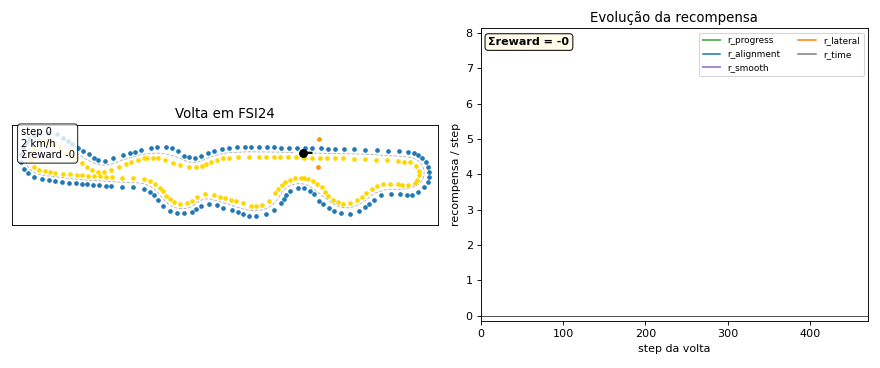

In [4]:
from IPython.display import Image as IPyImage
from scripts.make_reward_animation import make_gif

GIF = os.path.join(ROOT, "results", "figures", "reward_evolution.gif")
if HAVE_SB3 and HAVE_ENV:
    if not os.path.exists(GIF):                       # gera só se ainda não existir
        make_gif(out_path=GIF, track="FSCZ24", stride=3, fps=12)
    display(IPyImage(filename=GIF))                   # GIF embebido no notebook
else:
    print("Animação indisponível (stable-baselines3 / gymnasium em falta).")


#### **🔁 Ablação de reward — a jornada, iteração a iteração**

A recompensa de produção foi afinada por uma sequência de *fixes*, cada um a mudar ~uma coisa (progressão **ancorada no histórico git**). Aqui o algoritmo e o treino são mantidos **fixos** em todos os estágios (treino até à convergência, 500 k × 3 seeds) — só a recompensa muda.

Abaixo, **cada iteração** mostra o carro a conduzir (GIF, pista `FSE23` — a mais exigente onde as iterações ainda se distinguem, seed mediano) e **as modificações introduzidas nessa iteração**. No fim, a tabela geral e os gráficos comparativos.

In [5]:
# === Ablação de reward, iteração a iteração: GIF + modificações ===
import base64, glob
from IPython.display import HTML, display as _disp
from scripts.reward_iterations import STAGES

ITER_TRACK = "FSE23"   # pista mais exigente que ainda distingue as iterações
_GIF_DIR = os.path.join(ROOT, "results", "figures", "iter_gifs")
_PARAMS = [("offtrack_mode", "off-track"), ("progress_w", "progresso ×"),
           ("align_w", "align ×"), ("time_w", "tempo −"),
           ("smooth_w", "smooth ×"), ("smooth_db", "dead-band"),
           ("lateral_mode", "lateral"), ("lateral_w", "lateral ×"),
           ("stagnation", "anti-estag.")]

def _fmt(v):
    return v if isinstance(v, str) else f"{v:g}"

def _b64(p):
    with open(p, "rb") as f:
        return base64.b64encode(f.read()).decode()

def _iter_diff(k):
    c = STAGES[k - 1]["cfg"]
    if k == 1:
        return [("ponto de partida", "v0 — suicide policy")]
    p = STAGES[k - 2]["cfg"]
    return [(lab, f"{_fmt(p[key])} → {_fmt(c[key])}") for key, lab in _PARAMS if p[key] != c[key]]

def _iter_rollout(model, cfg, track, max_steps=2000):
    from scripts.reward_iterations import StagedRewardEnv
    env = StagedRewardEnv(reward_cfg=cfg, render_mode=None, randomize_track=False,
        domain_randomization=False, max_episode_steps=max_steps, tracks_dir=os.path.join(ROOT, "tracks"),
        track_name=track, use_orange_cones=True, terminate_on_cone=False, doo_cone_limit=999, max_laps=1)
    obs, info = env.reset(seed=0); tl = float(env.track_data["track_length"])
    xs, ys, ths, spd = [], [], [], []; done = False
    while not done:
        a, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(a); done = term or trunc
        xs.append(env.car.x); ys.append(env.car.y); ths.append(env.car.theta); spd.append(info["speed_kmh"])
    lp = info["laps_completed"]
    comp = 1.0 if lp >= 1 else min(1.0, info["total_progress"] / tl)
    td = env.track_data; env.close()
    return dict(xs=np.array(xs), ys=np.array(ys), ths=np.array(ths), spd=np.array(spd),
                td=td, comp=comp, lap=lp, vmean=float(np.mean(spd)))

def _iter_gif(k, track=ITER_TRACK, stride=5, fps=10):
    os.makedirs(_GIF_DIR, exist_ok=True)
    st = STAGES[k - 1]
    out = os.path.join(_GIF_DIR, f"iter{k:02d}_{st['slug']}_{track}.gif")
    cands = sorted(glob.glob(os.path.join(ROOT, "runs", "reward_iter",
                   f"stage{k:02d}_{st['slug']}", "seed*", "final_model.zip")))
    if not cands:
        return None, None
    from stable_baselines3 import SAC
    ros = [_iter_rollout(SAC.load(c, device="cpu"), st["cfg"], track) for c in cands]
    ro = sorted(ros, key=lambda r: r["comp"])[len(ros) // 2]   # seed mediano (representativo)
    if os.path.exists(out):
        return out, ro
    import matplotlib.pyplot as plt
    from matplotlib.animation import FuncAnimation, PillowWriter
    xs, ys, ths = ro["xs"], ro["ys"], ro["ths"]; td = ro["td"]; N = len(xs)
    dl = ro["lap"] >= 1; col = "#2ca02c" if dl else "crimson"
    fig, ax = plt.subplots(figsize=(4.4, 4.0))
    cl = td["centerline"]; ax.plot(cl[:, 0], cl[:, 1], "--", color="0.75", lw=0.8, zorder=1)
    for key, c in [("blue_cones", "tab:blue"), ("yellow_cones", "gold"), ("orange_cones", "darkorange")]:
        p = td.get(key, np.zeros((0, 2)))
        if len(p):
            ax.scatter(p[:, 0], p[:, 1], s=7, color=c, zorder=2)
    pad = 5
    ax.set_xlim(cl[:, 0].min() - pad, cl[:, 0].max() + pad)
    ax.set_ylim(cl[:, 1].min() - pad, cl[:, 1].max() + pad)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{k} {st['slug']} — {track}", fontsize=9)
    (trail,) = ax.plot([], [], "-", color=col, lw=1.6, alpha=0.8, zorder=3)
    (car,)   = ax.plot([], [], "o", color="black", ms=5, zorder=5)
    (head,)  = ax.plot([], [], "-", color="black", lw=2, zorder=4)
    txt = ax.text(0.03, 0.97, "", transform=ax.transAxes, va="top", fontsize=8,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    fig.tight_layout(pad=0.4)
    frames = list(range(0, N, stride)) + [N - 1]
    def upd(i):
        trail.set_data(xs[:i + 1], ys[:i + 1]); car.set_data([xs[i]], [ys[i]])
        head.set_data([xs[i], xs[i] + 2.8 * np.cos(ths[i])], [ys[i], ys[i] + 2.8 * np.sin(ths[i])])
        m = f"{ro['spd'][i]:.0f} km/h\npista: {100 * ro['comp']:.0f}%"
        if i == N - 1:
            m += "  ✓" if dl else ""
        txt.set_text(m)
        return trail, car, head, txt
    FuncAnimation(fig, upd, frames=frames, interval=1000 // fps, blit=False).save(
        out, writer=PillowWriter(fps=fps), dpi=85)
    plt.close(fig)
    return out, ro

def show_iteration(k):
    """Mostra a iteração k: GIF do carro (pista ITER_TRACK) + modificações dessa iteração."""
    if not (HAVE_SB3 and HAVE_ENV):
        print("Indisponível (stable-baselines3 / gymnasium em falta)."); return
    st = STAGES[k - 1]
    path, ro = _iter_gif(k)
    mods = "".join(f"<li><code>{lab}</code>: <b>{val}</b></li>" for lab, val in _iter_diff(k))
    gif = (f'<img src="data:image/gif;base64,{_b64(path)}" width="300" style="border-radius:6px"/>'
           if path else "<i>sem modelo</i>")
    out = ""
    if ro:
        parts = [f"{ro['vmean']:.0f} km/h", f"pista {100 * ro['comp']:.0f}%"]
        if ro["lap"] >= 1:
            parts.append("volta ✓")
        out = " · ".join(parts)
    accent = "#d62728" if k == 1 else ("#2ca02c" if k == len(STAGES) else "#cfcfcf")
    html = (
        f'<div style="border:1px solid #e6e6e6;border-left:5px solid {accent};border-radius:10px;padding:10px 16px;margin:8px 0;background:#fafafa;max-width:680px">'
        '<table style="border:none;border-collapse:collapse"><tr>'
        f'<td style="vertical-align:top;border:none">{gif}</td>'
        '<td style="vertical-align:top;border:none;padding-left:18px">'
        f'<div style="font-size:15px"><b>Iteração {k} — {st["slug"]}</b></div>'
        f'<div style="color:#555;font-size:12px;margin:3px 0 10px">{st["name"]}</div>'
        '<div style="font-size:12.5px"><b>Modificações nesta iteração:</b>'
        f'<ul style="margin:4px 0">{mods}</ul></div>'
        f'<div style="font-size:11px;color:#777">desfecho (seed mediano, {ITER_TRACK}): {out}</div>'
        '</td></tr></table></div>')
    _disp(HTML(html))

print(f"Helper pronto · pista dos GIFs: {ITER_TRACK} · usa show_iteration(1..{len(STAGES)}).")


Helper pronto · pista dos GIFs: FSE23 · usa show_iteration(1..6).


[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,"Iteração 1 — suicide_v0v0 — suicide policy (morte instantânea 1.3×hw)Modificações nesta iteração:ponto de partida: v0 — suicide policydesfecho (seed mediano, FSE23): 52 km/h · pista 47%"

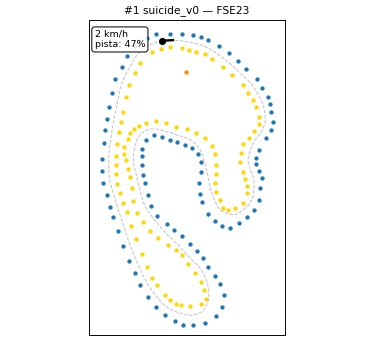

In [6]:
show_iteration(1)

[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,"Iteração 2 — offtrack_gradualv1 — off-course gradual (acaba a morte instantânea)Modificações nesta iteração:off-track: instant13 → gradualdesfecho (seed mediano, FSE23): 53 km/h · pista 100% · volta ✓"

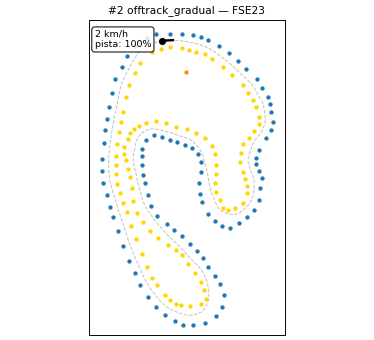

In [7]:
show_iteration(2)

[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,"Iteração 3 — steer_deadbandSteering −0.3 → −0.05 com dead-band 0.1Modificações nesta iteração:smooth ×: 0.3 → 0.05dead-band: 0 → 0.1desfecho (seed mediano, FSE23): 56 km/h · pista 100% · volta ✓"

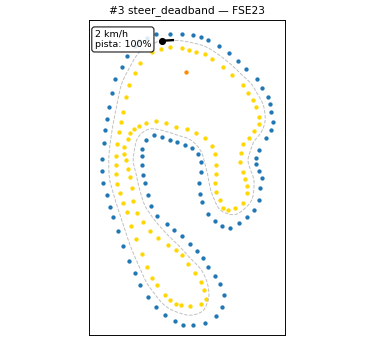

In [8]:
show_iteration(3)

[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,"Iteração 4 — lateral_pieceLateral quad ×0.2 → piecewise ×0.08 (linear dentro/quad fora)Modificações nesta iteração:lateral: quad → piecelateral ×: 0.2 → 0.08desfecho (seed mediano, FSE23): 64 km/h · pista 100% · volta ✓"

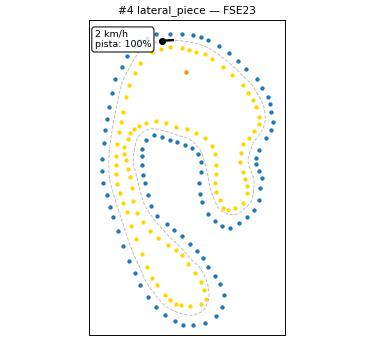

In [9]:
show_iteration(4)

[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,"Iteração 5 — rescale_signalsReescala dos sinais (progr.×2.0, align×0.4, tempo−0.005)Modificações nesta iteração:progresso ×: 1 → 2align ×: 0.1 → 0.4tempo −: 0.01 → 0.005desfecho (seed mediano, FSE23): 64 km/h · pista 100% · volta ✓"

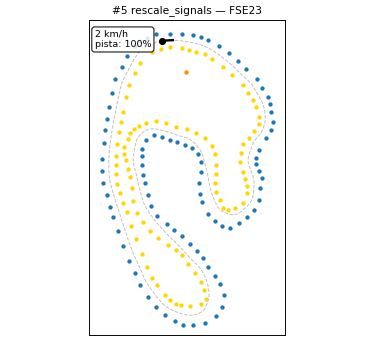

In [10]:
show_iteration(5)

[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,"Iteração 6 — anti_stagnation+ anti-estagnação (checkpoint DOO 2m/300 steps) = reward FINALModificações nesta iteração:anti-estag.: none → fulldesfecho (seed mediano, FSE23): 69 km/h · pista 100% · volta ✓"

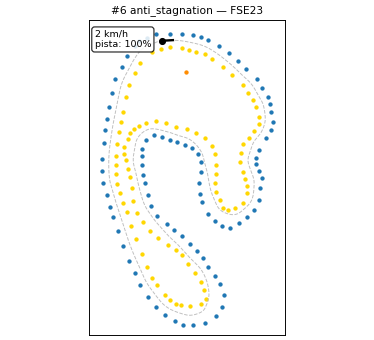

In [11]:
show_iteration(6)

#### **📋 Tabela geral — o que muda em cada iteração**

Configuração completa da recompensa por estágio (gerada do script; **amarelo** = mudou vs anterior).

In [12]:
from scripts.reward_iterations import STAGES

# Parâmetros da recompensa (chave no cfg -> rótulo legível). Treino é FIXO em todos.
PARAMS = [("offtrack_mode", "off-track"), ("progress_w", "progresso ×"),
          ("align_w", "align ×"), ("time_w", "tempo −"),
          ("smooth_w", "smooth ×"), ("smooth_db", "dead-band"),
          ("lateral_mode", "lateral"), ("lateral_w", "lateral ×"),
          ("stagnation", "anti-estag.")]

def _fmt(v):
    return v if isinstance(v, str) else f"{v:g}"

# tabela: linhas = iterações, colunas = parâmetros
idx = [f"{i}. {st['slug']}" for i, st in enumerate(STAGES, 1)]
tab = pd.DataFrame([{lab: _fmt(st["cfg"][k]) for k, lab in PARAMS} for st in STAGES], index=idx)

# diffs vs iteração anterior (a "história" em texto)
print("O que muda em cada iteração (só a recompensa — algoritmo e treino fixos):\n")
prev = None
for i, st in enumerate(STAGES, 1):
    c = st["cfg"]
    if prev is None:
        chg = "ponto de partida (v0 — suicide policy)"
    else:
        d = [f"{lab}: {_fmt(prev[k])} → {_fmt(c[k])}" for k, lab in PARAMS if prev[k] != c[k]]
        chg = "  •  ".join(d) if d else "(sem alteração)"
    print(f"  {i}. {st['slug']:17s} │ {chg}")
    prev = c

# tabela com as células alteradas (vs linha de cima) destacadas a amarelo
def _hl(col):
    styles = [""]
    for a, b in zip(col.iloc[:-1], col.iloc[1:]):
        styles.append("background-color:#fff3cd;font-weight:bold" if a != b else "")
    return styles

print()
display(tab.style.apply(_hl, axis=0)
          .set_caption("Configuração da recompensa por iteração — amarelo = mudou face à iteração anterior"))


O que muda em cada iteração (só a recompensa — algoritmo e treino fixos):

  1. suicide_v0        │ ponto de partida (v0 — suicide policy)
  2. offtrack_gradual  │ off-track: instant13 → gradual
  3. steer_deadband    │ smooth ×: 0.3 → 0.05  •  dead-band: 0 → 0.1
  4. lateral_piece     │ lateral: quad → piece  •  lateral ×: 0.2 → 0.08
  5. rescale_signals   │ progresso ×: 1 → 2  •  align ×: 0.1 → 0.4  •  tempo −: 0.01 → 0.005
  6. anti_stagnation   │ anti-estag.: none → full



,off-track,progresso ×,align ×,tempo −,smooth ×,dead-band,lateral,lateral ×,anti-estag.
1. suicide_v0,instant13,1,0.1,0.01,0.3,0,quad,0.2,none
2. offtrack_gradual,gradual,1,0.1,0.01,0.3,0,quad,0.2,none
3. steer_deadband,gradual,1,0.1,0.01,0.05,0.1,quad,0.2,none
4. lateral_piece,gradual,1,0.1,0.01,0.05,0.1,piece,0.08,none
5. rescale_signals,gradual,2,0.4,0.005,0.05,0.1,piece,0.08,none
6. anti_stagnation,gradual,2,0.4,0.005,0.05,0.1,piece,0.08,full


#### **📊 Gráficos comparativos** — à convergência (500 k × 3 seeds)

À convergência todos completam a pista; o que a recompensa distingue é a **qualidade** (velocidade, cones) e a **fiabilidade** (variância entre seeds).

,Fix,km/h,A mexer %,Pista %,Cones
#,,,,,
1,v0 — suicide policy (morte instantânea 1.3×hw),60.4,90.1,76.0,2.7
2,v1 — off-course gradual (acaba a morte instant...,48.7,98.1,82.5,3.4
3,Steering −0.3 → −0.05 com dead-band 0.1,74.3,99.7,100.0,4.0
4,Lateral quad ×0.2 → piecewise ×0.08 (linear de...,62.0,99.7,99.8,2.2
5,"Reescala dos sinais (progr.×2.0, align×0.4, te...",79.1,99.7,99.5,1.6
6,+ anti-estagnação (checkpoint DOO 2m/300 steps...,83.2,99.7,99.8,1.8


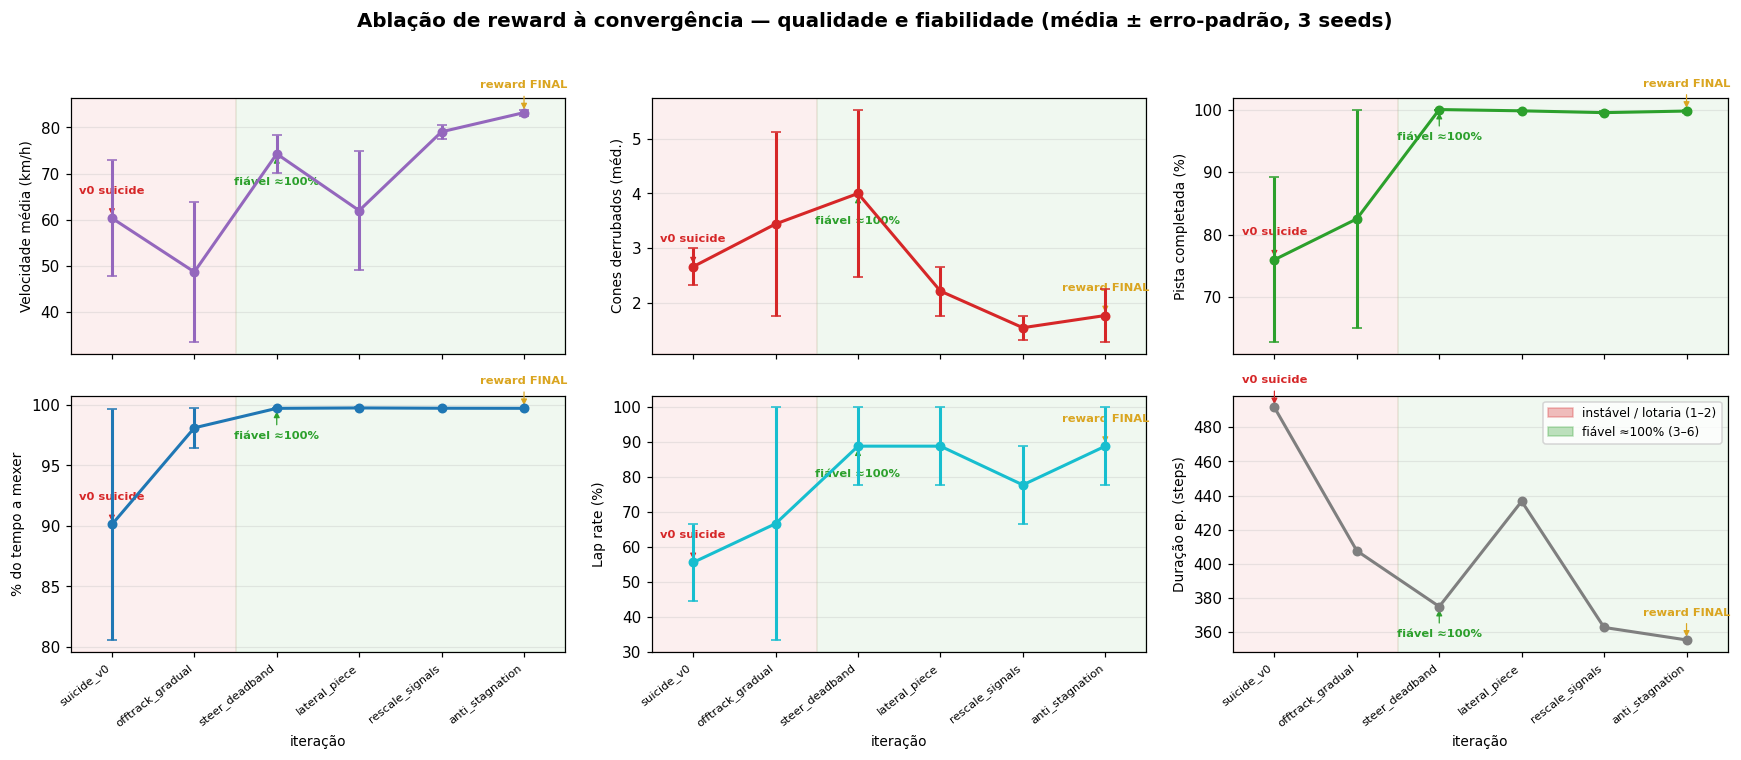


Trajetória por iteração na pista de avaliação (cor: iteração 1 → 6):


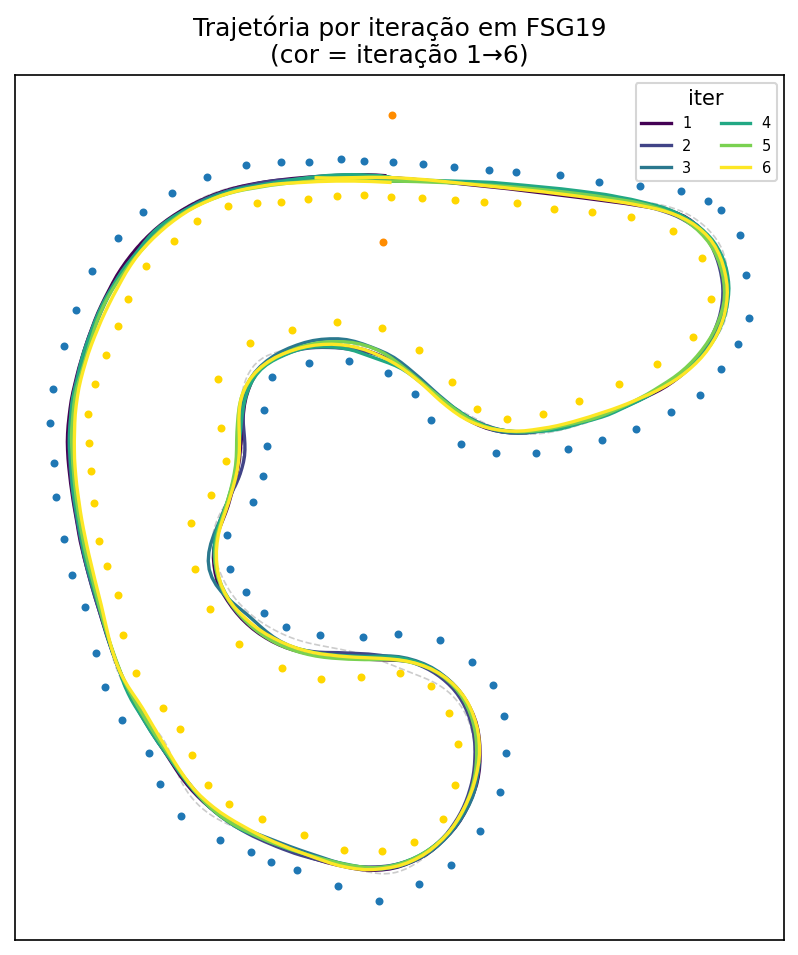

In [13]:
import math
ITER_CSV = os.path.join(ROOT, "results", "reward_iter", "metrics.csv")

if os.path.exists(ITER_CSV):
    di = pd.read_csv(ITER_CSV).sort_values("stage")
    x = di["stage"].values
    slugs = di["slug"].values
    n = len(x)
    ns = int(di["n_seeds"].iloc[0]) if "n_seeds" in di else 1
    sem = lambda std: np.asarray(std) / math.sqrt(ns) if ns >= 2 else np.zeros(n)  # erro-padrão

    moving = 100.0 * (1.0 - di["frac_stationary"].values)
    di_show = di.assign(**{"a_mexer_%": moving})
    show_cols = ["stage", "name", "mean_speed_kmh", "a_mexer_%", "completion", "mean_cones"]
    display(di_show[show_cols]
              .rename(columns={"stage": "#", "name": "Fix", "mean_speed_kmh": "km/h",
                               "a_mexer_%": "A mexer %", "completion": "Pista %",
                               "mean_cones": "Cones"}).round(1).set_index("#"))

    # À convergência, lidera com QUALIDADE (velocidade, cones) + FIABILIDADE (variância).
    specs = [
        ("mean_speed_kmh",  "mean_speed_kmh_std",  "Velocidade média (km/h)",  "#9467bd", False),
        ("mean_cones",      "mean_cones_std",      "Cones derrubados (méd.)",  "#d62728", False),
        ("completion",      "completion_std",      "Pista completada (%)",      "#2ca02c", False),
        ("MOVING",          "frac_stationary_std", "% do tempo a mexer",       "#1f77b4", False),
        ("lap_rate",        "lap_rate_std",        "Lap rate (%)",             "#17becf", False),
        ("mean_ep_len",     None,                  "Duração ep. (steps)",      "#7f7f7f", False),
    ]
    KEY = {1: ("v0 suicide", +16, "#d62728"),
           3: ("fiável ≈100%", -20, "#2ca02c"),
           n: ("reward FINAL", +16, "goldenrod")}
    BANDS = [(0.5, 2.5, "#d62728", "instável / lotaria (1–2)"),
             (2.5, n + 0.5, "#2ca02c", "fiável ≈100% (3–6)")]

    fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
    for ax, (k, sk, lab, col, pct) in zip(axes.flatten(), specs):
        if k == "MOVING":
            y = 100.0 * (1.0 - di["frac_stationary"].values)
            yerr = sem(100.0 * di[sk].values)
        else:
            y = di[k].values * (100 if pct else 1)
            yerr = sem(di[sk].values) if (sk and sk in di) else None
        for x0, x1, bcol, _ in BANDS:
            ax.axvspan(x0, x1, color=bcol, alpha=0.07, zorder=1)
        if yerr is not None:
            ax.errorbar(x, y, yerr=yerr, fmt="o-", color=col, lw=2, ms=5.5, capsize=3, zorder=4)
        else:
            ax.plot(x, y, "o-", color=col, lw=2, ms=5.5, zorder=4)
        for si, (txt, dy, kcol) in KEY.items():
            m = x == si
            if m.any():
                ax.annotate(txt, xy=(si, float(y[m][0])), xytext=(0, dy),
                            textcoords="offset points", ha="center", fontsize=7.5,
                            color=kcol, fontweight="bold",
                            arrowprops=dict(arrowstyle="-|>", color=kcol, lw=0.8, mutation_scale=8))
        ax.set_ylabel(lab, fontsize=9); ax.set_xlim(0.5, n + 0.5); ax.grid(alpha=0.25, axis="y")

    for ax in axes[1]:
        ax.set_xticks(x); ax.set_xticklabels(slugs, rotation=38, ha="right", fontsize=7.5)
        ax.set_xlabel("iteração", fontsize=9)

    from matplotlib.patches import Patch
    axes.flatten()[-1].legend(
        handles=[Patch(color=c, alpha=0.3, label=lab) for _, _, c, lab in BANDS],
        fontsize=8, loc="upper right")
    fig.suptitle(f"Ablação de reward à convergência — qualidade e fiabilidade (média ± erro-padrão, {ns} seeds)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    tj = os.path.join(ROOT, "results", "figures", "reward_iter_trajectories.png")
    if os.path.exists(tj):
        from IPython.display import Image as IPyImage
        print(f"\nTrajetória por iteração na pista de avaliação (cor: iteração 1 → {n}):")
        display(IPyImage(filename=tj, width=680))
else:
    print("Ainda não gerado. Corre (idealmente numa GPU):")
    print("  python scripts/reward_iterations.py --steps 500000 --n-seeds 3 --n-envs 4 --device cuda")
    print("Depois re-executa este notebook para ver as métricas e figuras aqui.")


#### **📈 Curvas de aprendizagem por iteração** (média ± erro-padrão sobre seeds)

Fração da pista completada **ao longo do treino**, por estágio. À convergência (500 k steps) **todos os estágios sobem para ~100%** — mas vê-se *como lá chegam*: as recompensas partidas (1, 2) sobem **mais devagar e com bandas largas** (treino instável, dependente da seed); as corrigidas (3–6) atingem 100% **mais cedo e com banda estreita** (treino fiável). A banda é o **erro-padrão da média**.

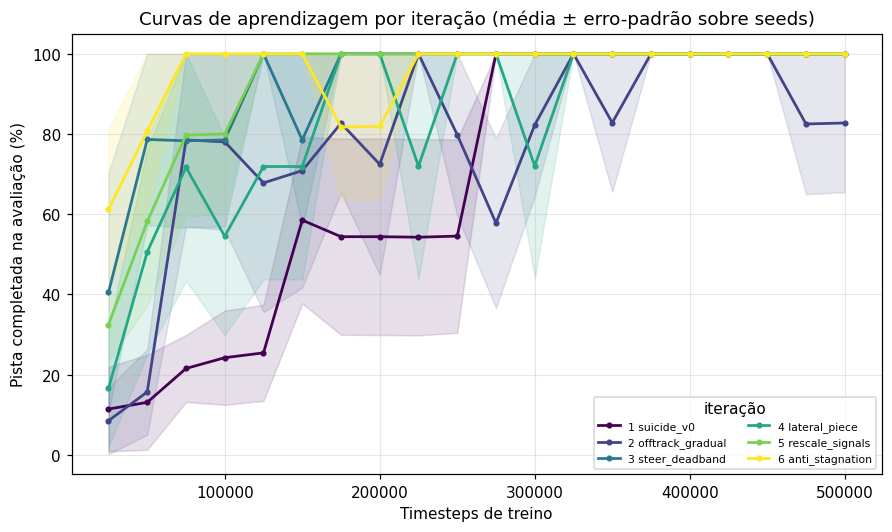

In [14]:
import glob, math
from scripts.reward_iterations import STAGES

_iter_root = os.path.join(ROOT, "runs", "reward_iter")

def _stage_curve(idx, slug, metric="completion"):
    """Lê os curve.npz de todas as seeds de um estágio → (ts, média, erro-padrão)."""
    files = sorted(glob.glob(os.path.join(_iter_root, f"stage{idx:02d}_{slug}", "seed*", "eval", "curve.npz")))
    series = []
    for f in files:
        d = np.load(f)
        if metric in d:
            series.append((d["timesteps"], d[metric]))
    if not series:
        return None, None, None
    L = min(len(t) for t, _ in series)
    ts = series[0][0][:L]
    M = np.stack([v[:L] for _, v in series], axis=0)
    nseeds = M.shape[0]
    std = M.std(axis=0, ddof=1) if nseeds > 1 else np.zeros(L)
    return ts, M.mean(axis=0), std / math.sqrt(max(1, nseeds))   # erro-padrão da média

fig, ax = plt.subplots(figsize=(9.5, 5.2))
cmap = plt.cm.viridis
n = len(STAGES)
found = False
for idx, st in enumerate(STAGES, start=1):
    ts, mean, se = _stage_curve(idx, st["slug"])
    if ts is None:
        continue
    found = True
    c = cmap((idx - 1) / max(1, n - 1))
    ax.plot(ts, mean, "-o", ms=3, lw=1.8, color=c, label=f"{idx} {st['slug']}")
    ax.fill_between(ts, mean - se, mean + se, color=c, alpha=0.13)

if found:
    ax.set_xlabel("Timesteps de treino")
    ax.set_ylabel("Pista completada na avaliação (%)")
    ax.set_title("Curvas de aprendizagem por iteração (média ± erro-padrão sobre seeds)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2, title="iteração", loc="best")
    plt.show()
else:
    print("Sem curvas ainda. Corre o treino para as gerar:")
    print("  python scripts/reward_iterations.py --steps 500000 --n-seeds 3 --n-envs 4 --device cuda")


**Leitura honesta (treino até à convergência, 500 k × 3 seeds).** Como esperado, o SAC é robusto: à convergência **quase todos os estágios completam a pista** (~100% a partir do estágio 3), por isso *"completa / não completa"* deixa de distinguir as recompensas. O que **persiste** é a *qualidade* e a *fiabilidade* da condução:

- **Fiabilidade — o sinal mais forte:** as recompensas partidas (1–2) são uma **lotaria** entre seeds (completar 76% / 82% com barras enormes; velocidade ±20 km/h); a partir do **dead-band (estágio 3)** o treino fica **fiável** (100% sem variância; velocidade final **83 ± 1 km/h**). No dashboard vê-se as barras de erro a **colapsar**.
- **Qualidade:** o reward final é o **mais rápido** (83 km/h) e o rescale/​final estão entre os mais limpos (~1.6–1.8 cones), contra ~4 cones no estágio sem o termo lateral *piecewise*.
- **Ressalva:** a *suavidade* (jerk do steering) não dá um sinal limpo aqui — está confundida (os estágios partidos quase não viram, logo têm pouco jerk), por isso não a destacamos.

Em suma: **a recompensa deixou de decidir *se* o carro conduz e passou a decidir *quão bem e quão fiavelmente*** — que é o efeito real do reward shaping quando o treino tem orçamento suficiente.

## 3. Resultados principais: SAC vs PPO

Comparação no **test split** (5 pistas inéditas, 10 episódios/pista, política determinística, *domain randomization* ativa). Valores $\bar{x}\pm\sigma$ entre *seeds*.

**Conclusão:** SAC e PPO têm *lap rate* equivalente (66 % vs 68 %, dentro do ruído amostral de ±5–8 pp), mas o **SAC é ~2× mais seguro** (2.4 vs 4.8 cones derrubados). O `SAC + Mirror Aug.` é o melhor compromisso global.

,model,n_seeds,lap_rate,cones,speed_kmh
0,SAC,3,66+/-0,2.4+/-0.6,76+/-1
1,PPO,3,68+/-7,4.8+/-0.9,79+/-1
2,SAC+Mirror Aug.,1,72,2.9,67


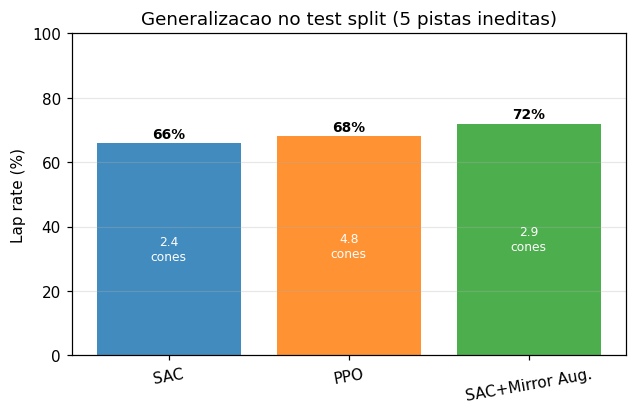

In [15]:
summary = pd.read_csv(os.path.join(AGG, "summary_main.csv"))
display(summary)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
plot_sac_vs_ppo(ax=ax)   # mesma figura do relatório, desenhada inline
plt.show()


### Desempenho por pista

A dificuldade depende muito do traçado: ambos completam quase sempre FSI24/FSCZ24/FSS22_V2, mas falham em **FSE24** e **FSG24** (curvas mais apertadas) — e é aí que o PPO mais derruba cones.

In [16]:
sac_pt = pd.read_csv(os.path.join(AGG, "per_track_SAC_test.csv"))
ppo_pt = pd.read_csv(os.path.join(AGG, "per_track_PPO_test.csv"))
print("SAC — per-track (test):"); display(sac_pt)
print("PPO — per-track (test):"); display(ppo_pt)


SAC — per-track (test):


,track,lap_rate,cones,speed_kmh,laptime_s,n_seeds
0,FSG24,33+/-5,3.0+/-0.5,77.3+/-2.3,17.4+/-0.3,3
1,FSI24,97+/-5,0.4+/-0.3,81.8+/-3.4,18.3+/-0.2,3
2,FSCZ24,100+/-0,1.8+/-0.8,79.2+/-3.6,14.4+/-0.2,3
3,FSE24,7+/-9,4.5+/-1.1,67.4+/-3.2,12.8,3
4,FSS22_V2,93+/-9,2.5+/-1.1,74.2+/-1.5,7.9+/-0.1,3


PPO — per-track (test):


,track,lap_rate,cones,speed_kmh,laptime_s,n_seeds
0,FSG24,30+/-22,6.4+/-1.7,81.8+/-1.0,17.2+/-0.1,3
1,FSI24,97+/-5,0.6+/-0.4,87.2+/-0.7,17.8+/-0.2,3
2,FSCZ24,100+/-0,2.2+/-0.4,83.6+/-1.2,13.9+/-0.2,3
3,FSE24,17+/-24,10.7+/-2.3,66.2+/-4.7,13.0,3
4,FSS22_V2,97+/-5,4.2+/-1.1,76.6+/-2.0,7.7+/-0.2,3


## 4. Curvas de aprendizagem (eficiência de amostras)

Reconstruímos as curvas a partir dos `eval/evaluations.npz` de cada *run* (recompensa média de 10 episódios de avaliação, por *checkpoint*), agregando média ± desvio sobre as 3 *seeds*. O SAC (*off-policy*) atinge o plateau com ~3M *steps*; o PPO precisa de ~6M para um desempenho comparável.

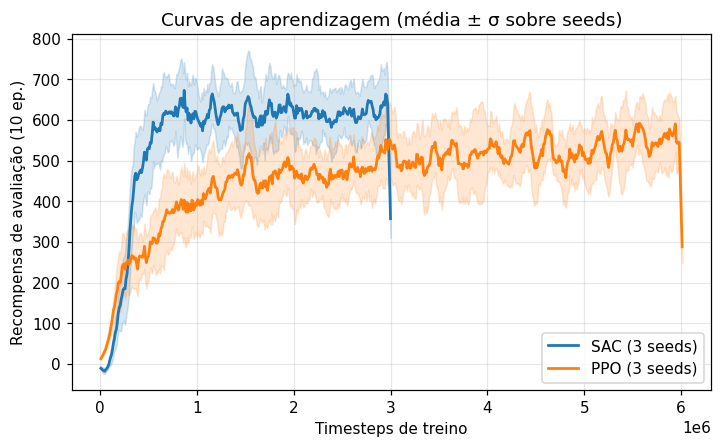

Figura agregada em alta qualidade: results/learning_curves.pdf


In [17]:
def load_eval_curve(run_dirs):
    # Média sobre seeds da recompensa de avaliação vs timesteps.
    # Cada npz tem timesteps (T,) e results (T, n_eval_eps).
    series = []
    common_ts = None
    for rd in run_dirs:
        f = os.path.join(ROOT, rd, "eval", "evaluations.npz")
        if not os.path.exists(f):
            continue
        d = np.load(f)
        ts = d["timesteps"]
        mean_per_ckpt = d["results"].mean(axis=1)
        series.append((ts, mean_per_ckpt))
    if not series:
        return None, None, None
    # alinhar pelo menor comprimento comum
    L = min(len(ts) for ts, _ in series)
    ts = series[0][0][:L]
    M = np.stack([m[:L] for _, m in series], axis=0)
    return ts, M.mean(axis=0), M.std(axis=0)

def smooth(y, k=7):
    if y is None or len(y) < k:
        return y
    return np.convolve(y, np.ones(k)/k, mode="same")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for label, runs, color in [
    ("SAC (3 seeds)", ["runs/sac_seed0","runs/sac_seed1","runs/sac_seed2"], "#1f77b4"),
    ("PPO (3 seeds)", ["runs/ppo_seed0","runs/ppo_seed1","runs/ppo_seed2"], "#ff7f0e"),
]:
    ts, mean, std = load_eval_curve(runs)
    if ts is None:
        continue
    m = smooth(mean); s = smooth(std)
    ax.plot(ts, m, color=color, label=label, lw=1.8)
    ax.fill_between(ts, m - s, m + s, color=color, alpha=0.18)
ax.set_xlabel("Timesteps de treino"); ax.set_ylabel("Recompensa de avaliação (10 ep.)")
ax.set_title("Curvas de aprendizagem (média ± σ sobre seeds)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print("Figura agregada em alta qualidade: results/learning_curves.pdf")


## 5. Ablações controladas (SAC, 2M steps, 1 seed)

15 variantes, cada uma alterando **uma** decisão de design face a um *baseline* curto (60 % *lap rate*, 3.2 cones).

⚠️ **Ler o *lap rate* em conjunto com os cones:** algumas variantes "ganham" voltas à custa de derrubar muitos mais cones. Ex.: *Alcance 8 m* sobe para 98 % de *lap rate* mas com **16 cones** e só 52 km/h — aprende a empurrar os cones em vez de os evitar. O FOV de 180° tem um *sweet spot* não-monotónico.

,slug,category,lap_rate,cones,speed_kmh,delta_lap_pp,delta_cones
0,abl_sac_range_8,Sensor,98,16.3,52,38,13.1
1,abl_sac_fov_90,Sensor,84,9.2,71,24,6.0
2,abl_sac_fov_360,Sensor,84,17.4,79,24,14.2
3,abl_sac_no_sensor_noise,Sensor,76,4.9,76,16,1.7
4,abl_sac_batch_512,Hiperparams,74,3.2,71,14,-0.0
5,abl_sac_te_aggressive,Hiperparams,72,3.0,76,12,-0.2
6,abl_sac_no_alignment,Recompensa,68,2.7,71,8,-0.5
7,abl_sac_buffer_1M,Hiperparams,68,3.2,73,8,0.0
8,abl_sac_lr_low,Hiperparams,68,4.9,68,8,1.7
9,abl_sac_no_dr,Domain Rand.,68,4.5,77,8,1.3


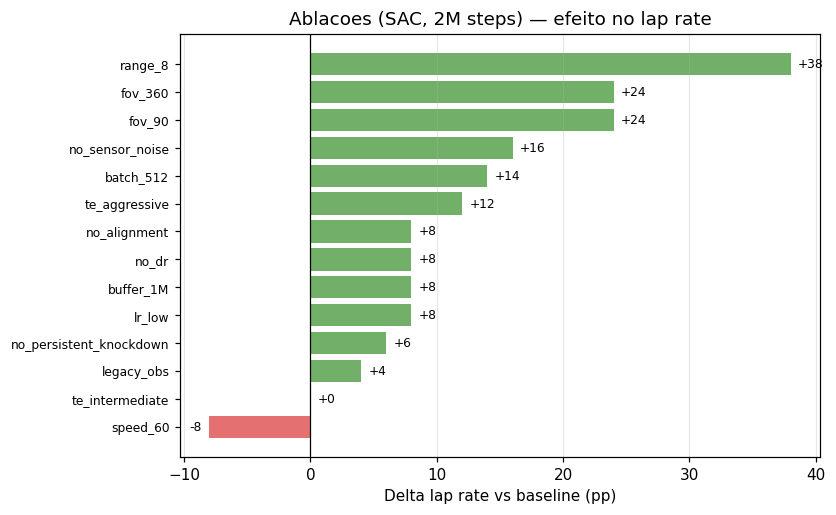

In [18]:
abl = pd.read_csv(os.path.join(AGG, "ablations.csv"))
display(abl.sort_values("delta_lap_pp", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7.5, 5.0))
plot_ablations(ax=ax)
plt.show()


## 6. Viés direcional e *mirror augmentation* — a descoberta principal

Avaliando os modelos em **pistas espelhadas em Y** (mesma geometria, curvas no sentido oposto — *held-out*), o *lap rate* **cai ~25 pp**: o agente sobre-ajustou a estrutura direcional do treino. Este *overfit* é **invisível** ao test split tradicional (que partilha essa estrutura).

Treinar com **mirror augmentation** (espelhar 50 % das pistas a cada *reset*) **elimina o viés**: 74 % em espelhadas (vs 40 %, **+34 pp**) e ainda melhora as originais (+6 pp), sem custo de segurança. O problema era estrutural ao treino, não ao algoritmo.

,model,test_lap_rate,mirror_lap_rate,delta_pp
0,SAC,66+/-0,40+/-11,-26
1,PPO,68+/-7,45+/-6,-23
2,SAC+Mirror Aug.,72,74,2


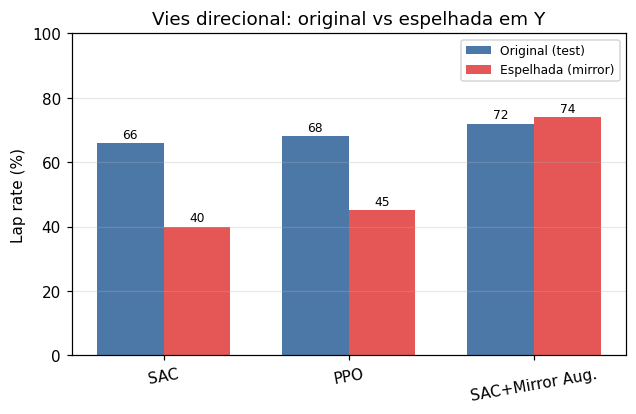

In [19]:
bias = pd.read_csv(os.path.join(AGG, "summary_direction_bias.csv"))
display(bias)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
plot_direction_bias(ax=ax)
plt.show()


## 7. Avaliação ao vivo de um modelo treinado

Carregamos um modelo treinado (Stable-Baselines3) e corremos episódios **headless** (sem render) numa pista do test split, imprimindo as métricas FS-AI. Corre em CPU (~0.5 s/episódio).

> Põe `RUN_LIVE = False` para saltar esta secção. Para **ver** o carro a conduzir (janela PyGame), corre no terminal:
> `python evaluate.py --mode sb3 --model runs/sac_seed0/best/best_model.zip --track FSCZ24 --n-episodes 3`

In [20]:
RUN_LIVE = True            # põe False para saltar
MODEL = "runs/sac_seed0/best/best_model.zip"
ALGO  = "sac"              # 'sac' ou 'ppo'
TRACKS = ["FSCZ24", "FSI24", "FSS22_V2"]   # subconjunto do test split
N_EPISODES = 3

def eval_live(model_path, algo, tracks, n_episodes=3):
    from stable_baselines3 import SAC, PPO
    from env.racing_env import FSRacingEnv
    Model = SAC if algo == "sac" else PPO
    model = Model.load(os.path.join(ROOT, model_path), device="cpu")
    rows = []
    for tr in tracks:
        env = FSRacingEnv(render_mode=None, randomize_track=False,
                          domain_randomization=True, max_episode_steps=3000,
                          tracks_dir=os.path.join(ROOT, "tracks"), track_name=tr,
                          use_orange_cones=True, terminate_on_cone=False,
                          doo_cone_limit=999, max_laps=1)
        laps, cones, speeds, rewards = [], [], [], []
        for ep in range(n_episodes):
            obs, info = env.reset(seed=ep)
            done = False; R = 0.0
            while not done:
                a, _ = model.predict(obs, deterministic=True)
                obs, r, term, trunc, info = env.step(a)
                done = term or trunc; R += r
            laps.append(info["laps_completed"]); cones.append(info["cones_hit"])
            speeds.append(info["speed_kmh"]); rewards.append(R)
        env.close()
        rows.append({"pista": tr,
                     "lap_rate_%": 100.0 * np.mean([l >= 1 for l in laps]),
                     "cones_méd": np.mean(cones),
                     "vel_méd_kmh": np.mean(speeds),
                     "reward_méd": np.mean(rewards)})
    return pd.DataFrame(rows)

if RUN_LIVE and HAVE_SB3 and HAVE_ENV:
    df_live = eval_live(MODEL, ALGO, TRACKS, N_EPISODES)
    display(df_live.round(1))
    print(f"\nModelo: {MODEL} | {N_EPISODES} episódios/pista | domain randomization ativa")
else:
    print("Secção saltada (RUN_LIVE=False ou dependências em falta).")


[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2
[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,pista,lap_rate_%,cones_méd,vel_méd_kmh,reward_méd
0,FSCZ24,100.0,1.3,75.7,851.7
1,FSI24,100.0,0.0,75.1,1085.6
2,FSS22_V2,66.7,1.0,68.6,391.2



Modelo: runs/sac_seed0/best/best_model.zip | 3 episódios/pista | domain randomization ativa


## 8. Demonstração final: um sucesso e uma falha (em pistas de treino)

Para terminar, pomos o **modelo final de produção** (`runs/sac_seed0`) a conduzir e mostramo-lo a correr em dois cenários **reais e determinísticos** (sem *domain randomization*, para serem reproduzíveis), ambos em **pistas de treino**:

- ✅ **Sucesso — FSG19:** completa a volta limpa, **0 cones** derrubados.
- ❌ **Falha — FSS22_V1:** sai de pista (*off-course* extremo > 5 m) ao fim de ~36 m e o episódio termina.

Mostramos a falha de propósito: é honesto e informativo. Que o modelo falhe consistentemente numa pista que **viu no treino** (e não apenas em pistas inéditas) é uma limitação genuína — e os modos de falha nesta pista (sair de fora / seguir em *contramão*) são coerentes com o **viés direcional** documentado na secção 6. Cada GIF marca a vermelho (`✗`) os cones derrubados e, no fim, a razão do término.

,

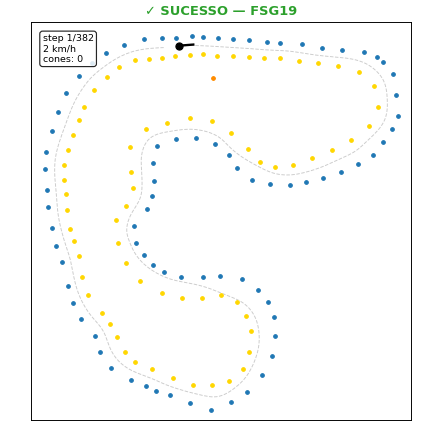
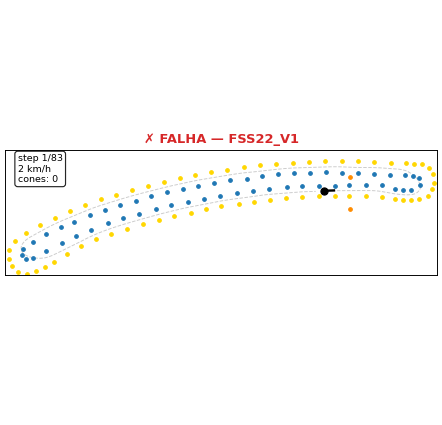

In [21]:
import base64
from IPython.display import HTML, display as ipy_display
from matplotlib.animation import FuncAnimation, PillowWriter

FINAL_MODEL = "runs/sac_seed0/best/best_model.zip"
DEMO = [  # (track, seed, é_sucesso, ficheiro_gif)
    ("FSG19",    0, True,  "final_demo_success.gif"),
    ("FSS22_V1", 0, False, "final_demo_fail.gif"),
]

def _demo_rollout(track, seed=0, max_steps=2000):
    from stable_baselines3 import SAC
    from env.racing_env import FSRacingEnv
    model = SAC.load(os.path.join(ROOT, FINAL_MODEL), device="cpu")
    env = FSRacingEnv(render_mode=None, randomize_track=False, domain_randomization=False,
                      max_episode_steps=max_steps, tracks_dir=os.path.join(ROOT, "tracks"),
                      track_name=track, use_orange_cones=True, terminate_on_cone=False,
                      doo_cone_limit=10, max_laps=1)
    obs, info = env.reset(seed=seed)
    xs, ys, ths, spd, knocked = [], [], [], [], []
    done = False
    while not done:
        a, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(a); done = term or trunc
        xs.append(env.car.x); ys.append(env.car.y); ths.append(env.car.theta); spd.append(info["speed_kmh"])
        kn = []
        for att, key in [("knocked_blue", "blue_cones"), ("knocked_yellow", "yellow_cones"),
                         ("knocked_orange", "orange_cones")]:
            for i in getattr(env, att, set()):
                p = env.track_data[key][i]; kn.append((p[0], p[1]))
        knocked.append(kn)
    out = dict(track=track, lap=info["laps_completed"], cones=info["cones_hit"],
               reason=getattr(env, "_termination_reason", ""), td=env.track_data,
               xs=np.array(xs), ys=np.array(ys), ths=np.array(ths), spd=np.array(spd), knocked=knocked)
    env.close(); return out

def _demo_gif(out_path, ro, success, stride=4, fps=14):
    import matplotlib.pyplot as plt
    td = ro["td"]; xs, ys, ths, spd = ro["xs"], ro["ys"], ro["ths"], ro["spd"]; N = len(xs)
    col = "#2ca02c" if success else "#d62728"
    fig, ax = plt.subplots(figsize=(5.2, 5.0))
    cl = td["centerline"]; ax.plot(cl[:, 0], cl[:, 1], "--", color="0.8", lw=0.8, zorder=1)
    for key, c in [("blue_cones", "tab:blue"), ("yellow_cones", "gold"), ("orange_cones", "darkorange")]:
        p = td.get(key, np.zeros((0, 2)))
        if len(p): ax.scatter(p[:, 0], p[:, 1], s=9, color=c, zorder=2)
    pad = 5
    ax.set_xlim(cl[:, 0].min() - pad, cl[:, 0].max() + pad)
    ax.set_ylim(cl[:, 1].min() - pad, cl[:, 1].max() + pad)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{'✓ SUCESSO' if success else '✗ FALHA'} — {ro['track']}",
                 color=col, fontweight="bold", fontsize=11)
    (trail,) = ax.plot([], [], "-", color=col, lw=1.8, alpha=0.8, zorder=3)
    (car,)   = ax.plot([], [], "o", color="black", ms=6, zorder=6)
    (head,)  = ax.plot([], [], "-", color="black", lw=2, zorder=5)
    knsc = ax.scatter([], [], s=70, marker="x", color="red", lw=2, zorder=7)
    txt = ax.text(0.03, 0.97, "", transform=ax.transAxes, va="top", fontsize=8,
                  bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    fig.tight_layout(pad=0.4)
    frames = list(range(0, N, stride)) + [N - 1]
    def upd(i):
        trail.set_data(xs[:i + 1], ys[:i + 1]); car.set_data([xs[i]], [ys[i]])
        head.set_data([xs[i], xs[i] + 3 * np.cos(ths[i])], [ys[i], ys[i] + 3 * np.sin(ths[i])])
        kn = ro["knocked"][i]
        knsc.set_offsets(np.array(kn) if kn else np.empty((0, 2)))
        msg = f"step {i+1}/{N}\n{spd[i]:.0f} km/h\ncones: {len(kn)}"
        if i == N - 1: msg += f"\n{'volta completa ✓' if success else ro['reason']}"
        txt.set_text(msg)
        return trail, car, head, knsc, txt
    anim = FuncAnimation(fig, upd, frames=frames, interval=1000 // fps, blit=False)
    anim.save(out_path, writer=PillowWriter(fps=fps), dpi=85); plt.close(fig)

def _b64(p):
    with open(p, "rb") as f: return base64.b64encode(f.read()).decode()

if HAVE_SB3 and HAVE_ENV:
    cells = []
    for track, seed, success, fname in DEMO:
        gif = os.path.join(ROOT, "results", "figures", fname)
        if not os.path.exists(gif):                       # gera só se não existir (cache)
            ro = _demo_rollout(track, seed)
            _demo_gif(gif, ro, success)
            print(f"[{'✓' if success else '✗'}] {track}: lap={ro['lap']} cones={ro['cones']} :: {ro['reason'] or 'volta completa'}")
        border = "#2ca02c" if success else "#d62728"
        cells.append(
            f'<td style="text-align:center;padding:8px">'
            f'<img src="data:image/gif;base64,{_b64(gif)}" width="340" '
            f'style="border:3px solid {border};border-radius:6px"/></td>')
    ipy_display(HTML(f'<table style="border-collapse:collapse"><tr>{"".join(cells)}</tr></table>'))
else:
    print("Demo indisponível (stable-baselines3 / gymnasium em falta).")


## 9. Como reproduzir tudo a partir da linha de comandos

```bash
# Instalar dependências
pip install -r requirements.txt

# Testes unitários (ambiente, modelo de veículo, splits)
pytest -q

# Treino SAC (3M steps) e PPO (6M steps) — requer GPU
python train.py --mode sb3 --algo sac --total-steps 3000000 --split train --seed 0 --run-name sac_seed0
python train.py --mode sb3 --algo ppo --total-steps 6000000 --split train --seed 0 --run-name ppo_seed0

# SAC com mirror augmentation (corrige o viés direcional)
python train.py --mode sb3 --algo sac --total-steps 3000000 --split train --seed 0 --mirror-augment --run-name sac_mirror_aug

# Ablação de reward (6 iterações × 3 seeds, até à convergência) — métricas, curvas e figuras
python scripts/reward_iterations.py --steps 500000 --n-seeds 3 --n-envs 4 --device cuda

# Avaliação per-track (gera CSV + tabela LaTeX)
python scripts/eval_per_track.py --model runs/sac_seed0/best/best_model.zip --algo sac --split test --n-episodes 10

# Visualização PyGame (ver o carro a conduzir)
python evaluate.py --mode sb3 --model runs/sac_seed0/best/best_model.zip --track FSCZ24 --n-episodes 3

# Regenerar as figuras deste notebook / do relatório
python scripts/make_report_figures.py
```

---
O relatório completo está em [`docs/report.pdf`](../docs/report.pdf). Detalhes de arquitetura e de cada componente estão no [`README.md`](../README.md).